***Módulos a Importar***

In [55]:
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Punto 1

0. Funciones a Utilizar

In [56]:
# Sabiendo theta1 y theta2, calcula la posicion x y y del punto 1 (Direct Kinematics)

def lista_posiciones(lista_theta1, lista_theta2):

  lista_posx_p1 = []
  lista_posy_p1 = []

  for elemento_unico in range(len(lista_theta1)):
    theta1_unico = lista_theta1[elemento_unico]
    theta2_unico = lista_theta2[elemento_unico]
    lista_posx_p1.append(f_posicionx_p1(theta1_unico, theta2_unico))
    lista_posy_p1.append(f_posiciony_p1(theta1_unico, theta2_unico))

  return lista_posx_p1, lista_posy_p1

In [57]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, graficar su movimiento en el espacio

def graficar_puntos(x1, y1, x2, y2, x3, y3):
    plt.figure(figsize=(8, 8))

    plt.plot(x1, y1, label="Punto 1", color='maroon')
    plt.plot(x2, y2, label="Punto 2", color = 'forestgreen')
    plt.plot(x3, y3, label="Punto 3", color = 'steelblue')

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Trayectoria de los 3 puntos")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    plt.show()

In [58]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, graficar su variación de acuerdo al movimiento del actuador lineal s

def graficar_posiciones_actuador(x1, y1, x2, y2, x3, y3, s):

    # Punto 1
    plt.figure(figsize=(10, 6))
    plt.plot(s, x1, label='P1 - x', color='firebrick')
    plt.plot(s, y1, label='P1 - y', color = 'teal')
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Posición [mm]')
    plt.title('Posición del punto P1 vs desplazamiento')
    plt.grid()
    plt.legend()
    plt.show()

    # Punto 2
    plt.figure(figsize=(10, 6))
    plt.plot(s, x2, label='P2 - x', color='firebrick')
    plt.plot(s, y2, label='P2 - y', color = 'teal')
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Posición [mm]')
    plt.title('Posición del punto P2 vs desplazamiento')
    plt.grid()
    plt.legend()
    plt.show()

    # Punto 3
    plt.figure(figsize=(10, 6))
    plt.plot(s, x3, label='P3 - x', color='firebrick')
    plt.plot(s, y3, label='P3 - y', color = 'teal')
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Posición [mm]')
    plt.title('Posición del punto P3 vs desplazamiento')
    plt.grid()
    plt.legend()
    plt.show()


In [59]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, calcular sus respectivos ángulos con respecto al Eje Vertical

def angulo_respecto_a_eje(posicionesx, posicionesy):
    angulos = []
    for elemento in range(len(posicionesx)):
        componentex = posicionesx[elemento]
        componentey = posicionesy[elemento]
        angulo_unico = np.arctan(componentex/componentey)
        angulo_unico = np.rad2deg(angulo_unico)
        angulos.append(angulo_unico)
    return angulos

In [60]:
# Sabiendo los ángulos de cada punto con respecto al Eje Vertical, graficar su variación de acuerdo al movimiento del actuador lineal s

def graficar_angulos_actuador(angulos1, angulos2, angulos3, s):

    plt.figure(figsize=(10, 6))
    plt.plot(s, angulos1, label='Angulo P1 - x', color = 'dodgerblue' )
    plt.plot(s, angulos2, label='Angulo P2 - x', color = 'rebeccapurple' )
    plt.plot(s, angulos3, label='Angulo P3 - x', color = 'darkorange' )
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Ángulo [deg]')
    plt.title('Ángulos de los Puntos respecto al Eje X')
    plt.grid()
    plt.legend()
    plt.show()

1. Definición del Modelo

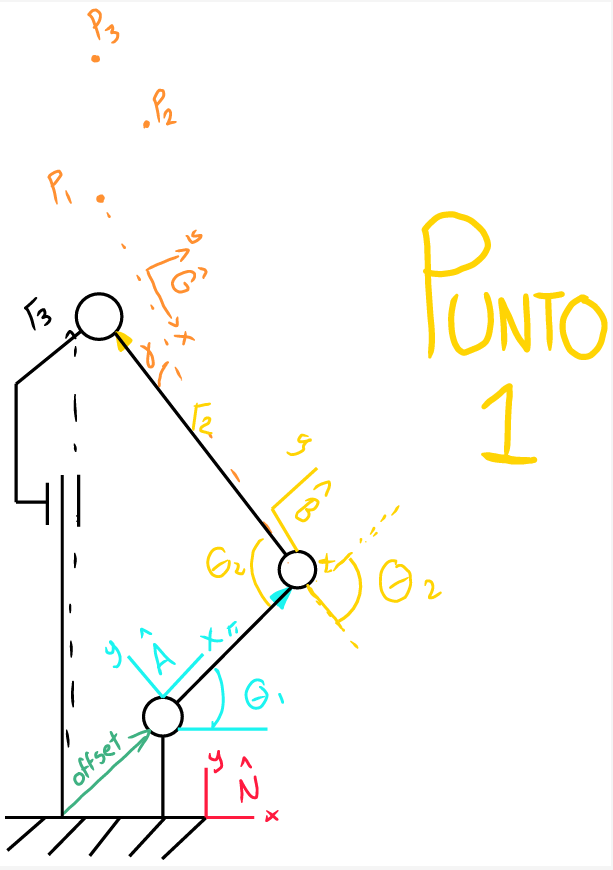

In [61]:
# 1. Definición de Variables
theta, theta2 = dynamicsymbols('theta theta2')
l1, l2, l3_min, s, px, py = sp.symbols('l1 l2 l3_min s px py')

# s == Que tanto se esta expandiendo desde su punto de compresión maximo (entre 0 / completamente comprimido y 20 / completamente estirado)

# 2. Definición de Marcos
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', (theta, N.z))
B = A.orientnew('B', 'Axis', (-theta2, A.z))

# 3. Definición de Medidas y Vectores
l3 = l3_min + s
offset = px*N.x + py*N.y
r1 = l1*A.x
r2 = -l2*B.x
r3 = l3*N.y + offset

# 4. Definición de Ecuaciones y Loop
loop = r1 + r2 - r3 
eq_x = loop.dot(N.x)
eq_y = loop.dot(N.y)
eq = [eq_x, eq_y]

# 5. Conversión a función numérica
fun_eq = sp.lambdify((theta, theta2, l1, l2, l3_min, s, px, py), eq, "numpy")

# 6. Fijación de Valores
val = {
    l1: 30,
    l2: 30,
    l3_min: 30,
    px: 10,
    py: 5,
}
s_val = np.linspace(0, 20, 100)

# 7. Aproach Numérico (hallar theta1 y theta2)

estimacion_angulos = [np.radians(45), np.radians(90)]
theta1_sol = []
theta2_sol = []

for s_num in s_val:
  regleta = lambda v: fun_eq(*v, val[l1],val[l2], val[l3_min],s_num,val[px],val[py])
  solu=fsolve(regleta,estimacion_angulos)
  theta1_sol.append(solu[0])
  theta2_sol.append(solu[1])
  estimacion_angulos=solu


print(theta1_sol)

[0.3735726061346202, 0.3791689667368741, 0.38476391310247826, 0.3903578716690549, 0.39595126868827213, 0.4015445304606573, 0.4071380835727231, 0.4127323551367031, 0.4183277730332381, 0.42392476615737396, 0.4295237646682475, 0.4351252002428447, 0.4407295063342363, 0.4463371184347184, 0.45194847434429314, 0.4575640144449563, 0.4631841819812776, 0.4688094233477806, 0.47444018838366236, 0.4800769306754141, 0.48572010786794184, 0.4913701819848157, 0.49702761975831405, 0.5026928929699669, 0.5083664788023475, 0.5140488602029071, 0.5197405262606934, 0.5254419725968541, 0.5311537017698817, 0.5368762236966186, 0.5426100560901124, 0.548355724915488, 0.554113764865082, 0.5598847198541708, 0.5656691435387303, 0.571467599856761, 0.5772806635948294, 0.5831089209816044, 0.5889529703103035, 0.59481342259211, 0.60069090224279, 0.6065860478049137, 0.612499512708288, 0.6184319660714152, 0.6243840935470343, 0.6303565982150642, 0.6363502015265491, 0.6423656443025281, 0.6484036877921012, 0.6544651147943463, 

Plus. Gráfica Ángulos

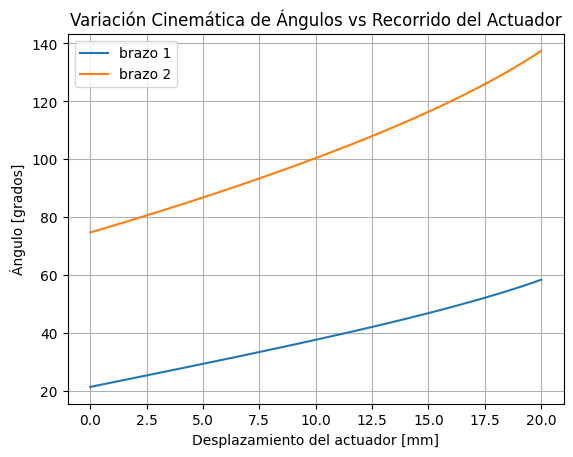

In [62]:
plt.plot(s_val, np.degrees(theta1_sol), label=r'brazo 1')
plt.plot(s_val, np.degrees(theta2_sol), label=r'brazo 2')
plt.xlabel('Desplazamiento del actuador [mm]')
plt.ylabel('Ángulo [grados]')
plt.title('Variación Cinemática de Ángulos vs Recorrido del Actuador')
plt.grid()
plt.legend()
plt.show()

B. Trayectoria en el Espacio de los Puntos

In [63]:
dp1 = sp.symbols('dp1')
gamma1 = sp.symbols('gamma1')
valores_gamma = {gamma1:np.deg2rad(35), dp1:45}

vector_origen_b = offset + r1

G = A.orientnew('G', 'Axis', (-theta2 - gamma1, A.z))

vector_p1 = (vector_origen_b + dp1 *-G.x).express(N).subs(val).subs(valores_gamma)

f_posicionx_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.x),"numpy")
f_posiciony_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.y),"numpy")


posicionesx_p1, posicionesy_p1 = lista_posiciones(theta1_sol,theta2_sol)

vp1_p2 = [5,15]
vp1_p3 = [0,30]

posicionesx_p2 = [xi + vp1_p2[0] for xi in posicionesx_p1]
posicionesy_p2 = [yi + vp1_p2[1] for yi in posicionesy_p1]
posicionesx_p3 = [xi + vp1_p3[0] for xi in posicionesx_p1]
posicionesy_p3 = [yi + vp1_p3[1] for yi in posicionesy_p1]

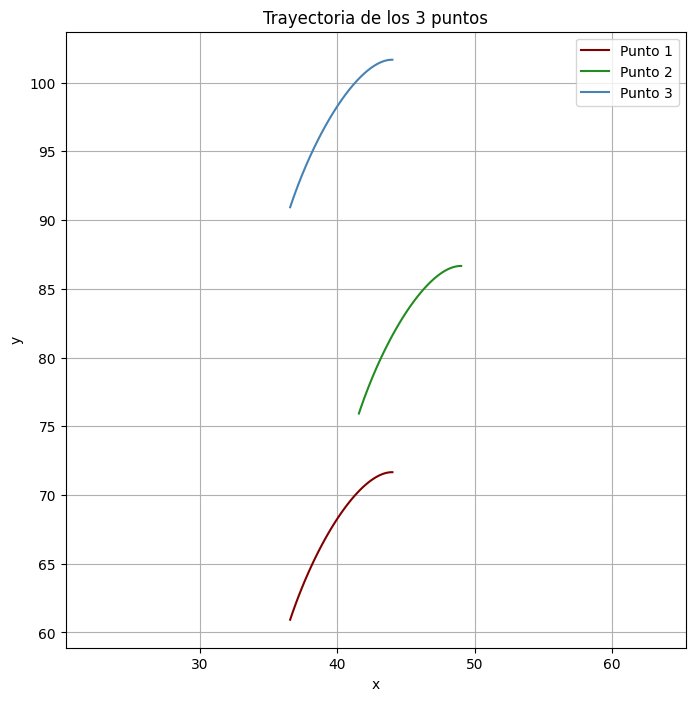

In [64]:
graficar_puntos(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3)

C. Posición en Función del Desplazamiento del Actuador Lineal

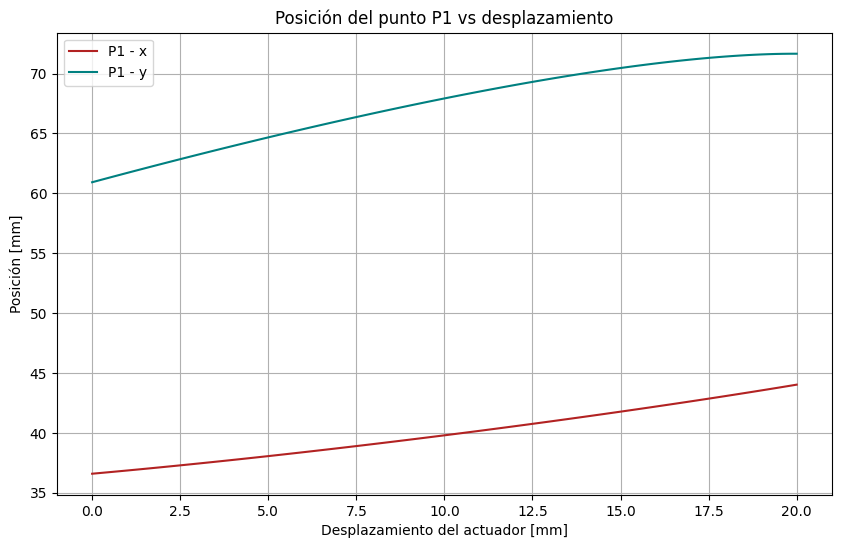

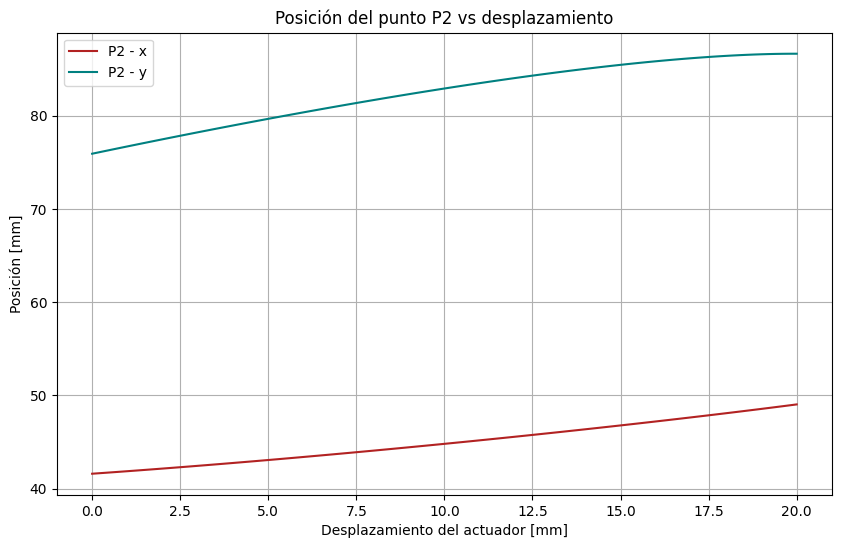

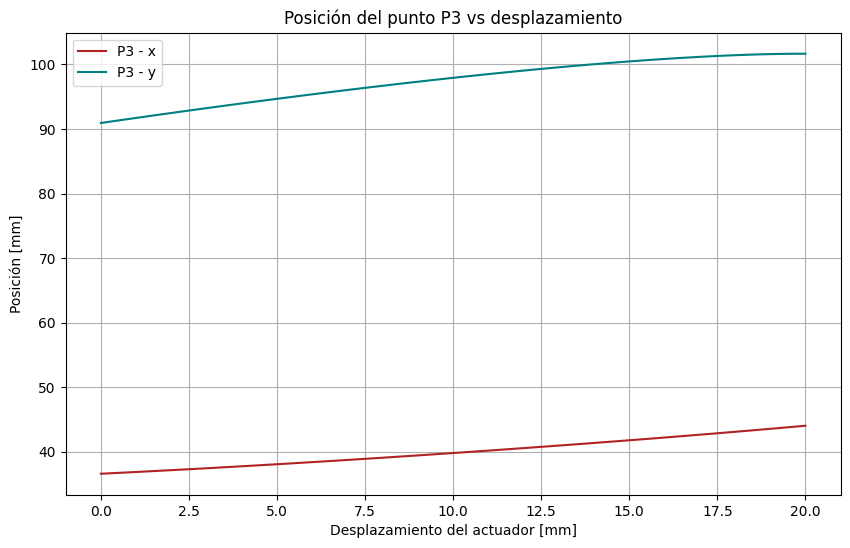

In [65]:
graficar_posiciones_actuador(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3, s_val)

D. Ángulos Respecto al Eje X (En Nuestro Caso Y)

In [66]:
angulos_p1 = angulo_respecto_a_eje(posicionesx_p1, posicionesy_p1)
angulos_p2 = angulo_respecto_a_eje(posicionesx_p2, posicionesy_p2)
angulos_p3 = angulo_respecto_a_eje(posicionesx_p3, posicionesy_p3)

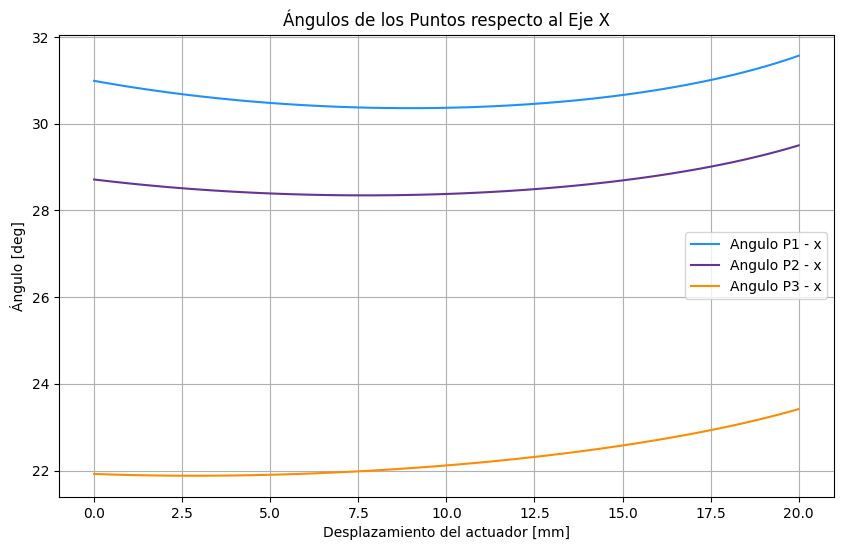

In [67]:
graficar_angulos_actuador(angulos_p1, angulos_p2, angulos_p3, s_val)

E. Datos de Interés para Análisis

In [68]:
# Todos los valores son Respecto al Punto 2 (Promedio)

min_y = min(posicionesy_p2)
max_y = max(posicionesy_p2)
min_x = min(posicionesx_p2)
max_x = max(posicionesx_p2)

print(f" Y Min {min_y}")
print(f" Y Max {max_y}")
print(f" X Min {min_x}")
print(f" X Max {max_x}")

angulo_min_vert = min(angulos_p2)
angulo_max_vert = max(angulos_p2)

print(f" Angulo Min {angulo_min_vert}")
print(f" Angulo Max {angulo_max_vert}")




 Y Min 75.92839395950219
 Y Max 86.65844872329394
 X Min 41.59191992192633
 X Max 49.02852583464669
 Angulo Min 28.346909775602644
 Angulo Max 29.499766878632123


# Punto 2

0. Funciones Nuevas a Utilizar

In [69]:
# Sabiendo theta1 y theta2 Y S, calcula la posicion x y y del punto 1 (Direct Kinematics)

def lista_posiciones_s(lista_theta1, lista_theta2, s_val):

  lista_posx_p1 = []
  lista_posy_p1 = []

  for elemento_unico in range(len(lista_theta1)):
    theta1_unico = lista_theta1[elemento_unico]
    theta2_unico = lista_theta2[elemento_unico]
    s_unico = s_val[elemento_unico]
    lista_posx_p1.append(f_posicionx_p1(theta1_unico, theta2_unico, s_unico))
    lista_posy_p1.append(f_posiciony_p1(theta1_unico, theta2_unico, s_unico))

  return lista_posx_p1, lista_posy_p1

1. Definición del Modelo TOCA CAMBIAR EL ESQUEMÁTICO

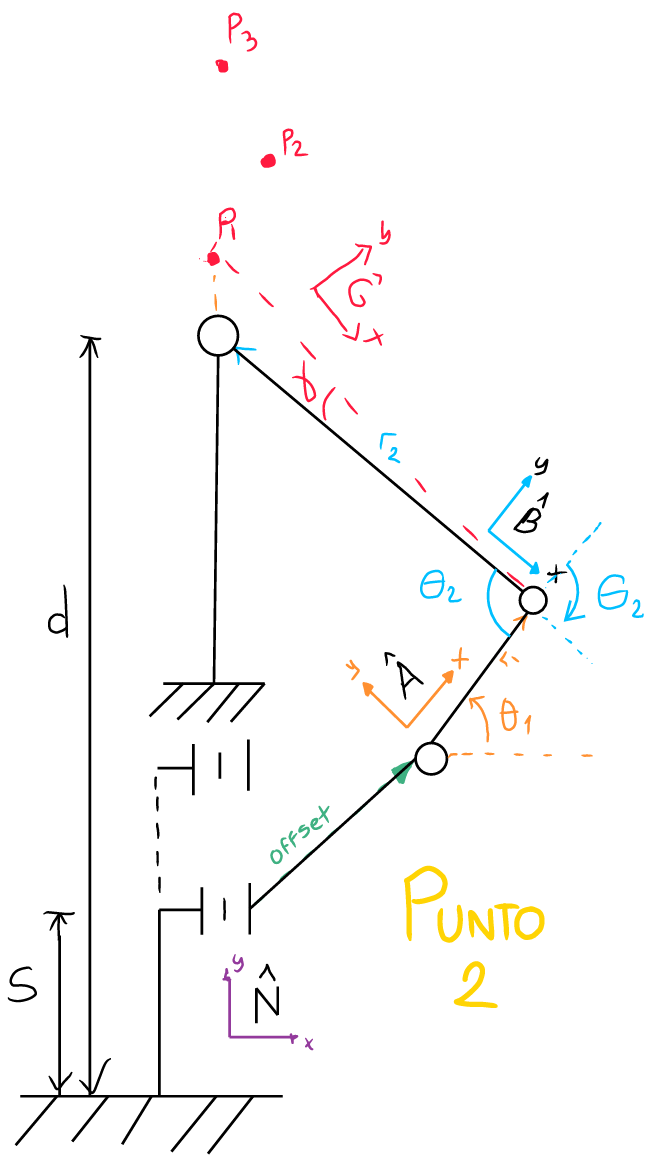

In [70]:
# 1. Definición de Variables
theta, theta2 = dynamicsymbols('theta theta2')
ox, oy, l1,l2, d_fija, s = sp.symbols('ox oy l1 l2 d_fija s')

# 2. Definición de Marcos
N = ReferenceFrame('N')
A= N.orientnew('A', 'Axis', (theta, N.z))
B= A.orientnew('B', 'Axis', (-theta2, N.z))

# 3. Definición de Medidas y Vectores
l3= d_fija
offset= ox*N.x +oy*N.y
subida_piston = s*N.y
r1= l1*A.x
r2= -l2*B.x
r3= l3*N.y 

# 4. Definición de Ecuaciones y Loop
loop= subida_piston + r1+r2-r3 + offset
eqx= loop.dot(N.x)
eqy= loop.dot(N.y)
eq=[eqx, eqy]

# 5. Conversión a Función Numérica
fun_eq=sp.lambdify((theta, theta2,ox,oy,l1,l2,d_fija,s),eq,"numpy")

# 6. Fijación de Valores
val={ox:7, oy:2 ,l1:40, l2:50,d_fija:60}
s_val=np.linspace(0,20,100)

# 7. Approach Numérico (hallar theta1 y theta2)
angulos_estimados=[np.radians(50),np.radians(70)]
theta1_sol=[]
theta2_sol=[]
for s_num  in s_val:
  regleta=lambda v: fun_eq( *v,val[ox],val[oy],val[l1],val[l2],val[d_fija],s_num)
  solu=fsolve(regleta, angulos_estimados)
  theta1_sol.append(solu[0])
  theta2_sol.append(solu[1])
  angulos_estimados= solu


Plus. Gráfica Ángulos

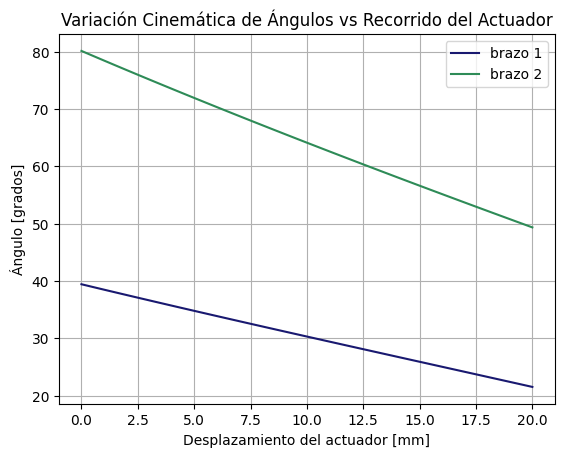

In [71]:
plt.plot(s_val, np.degrees(theta1_sol), label=r'brazo 1', color='midnightblue')
plt.plot(s_val, np.degrees(theta2_sol), label=r'brazo 2', color='seagreen')
plt.xlabel('Desplazamiento del actuador [mm]')
plt.ylabel('Ángulo [grados]')
plt.title('Variación Cinemática de Ángulos vs Recorrido del Actuador')
plt.grid()
plt.legend()
plt.show()

B. Trayectoria en el Espacio de los Puntos

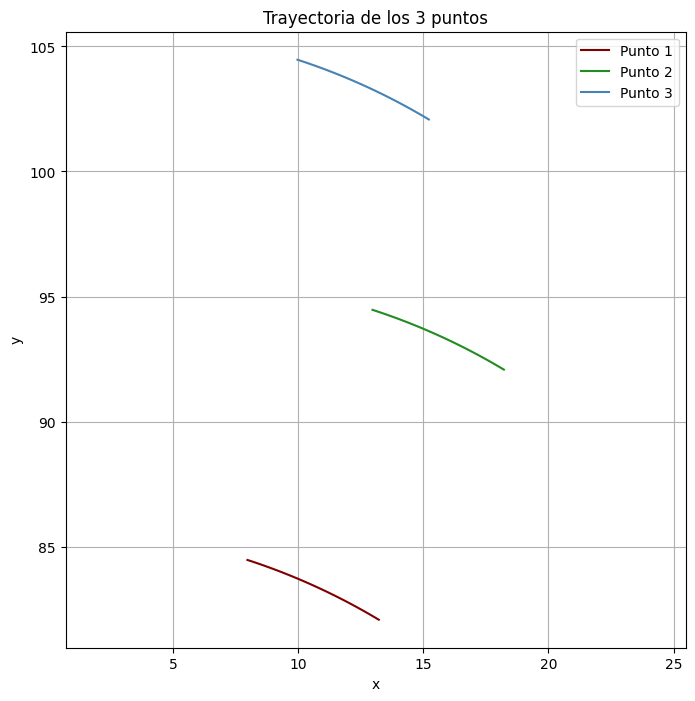

In [72]:
dp1 = sp.symbols('dp1')
gamma = sp.symbols('gamma')
valores_gamma = {gamma:np.deg2rad(25), dp1:60}

vector_origen_b = subida_piston + offset + r1

G = A.orientnew('G', 'Axis', (-theta2 - gamma, A.z))

vector_p1 = (vector_origen_b + dp1 *-G.x).express(N).subs(val).subs(valores_gamma)
display(vector_p1)

f_posicionx_p1 = sp.lambdify((theta,theta2,s),vector_p1.dot(N.x),"numpy")
f_posiciony_p1 = sp.lambdify((theta,theta2,s),vector_p1.dot(N.y),"numpy")


posicionesx_p1, posicionesy_p1 = lista_posiciones_s(theta1_sol,theta2_sol, s_val)


vp1_p2 = [5,10]
vp1_p3 = [2,20]

posicionesx_p2 = [xi + vp1_p2[0] for xi in posicionesx_p1]
posicionesy_p2 = [yi + vp1_p2[1] for yi in posicionesy_p1]
posicionesx_p3 = [xi + vp1_p3[0] for xi in posicionesx_p1]
posicionesy_p3 = [yi + vp1_p3[1] for yi in posicionesy_p1]



graficar_puntos(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3)

C. Posición en Función del Desplazamiento del Actuador Lineal

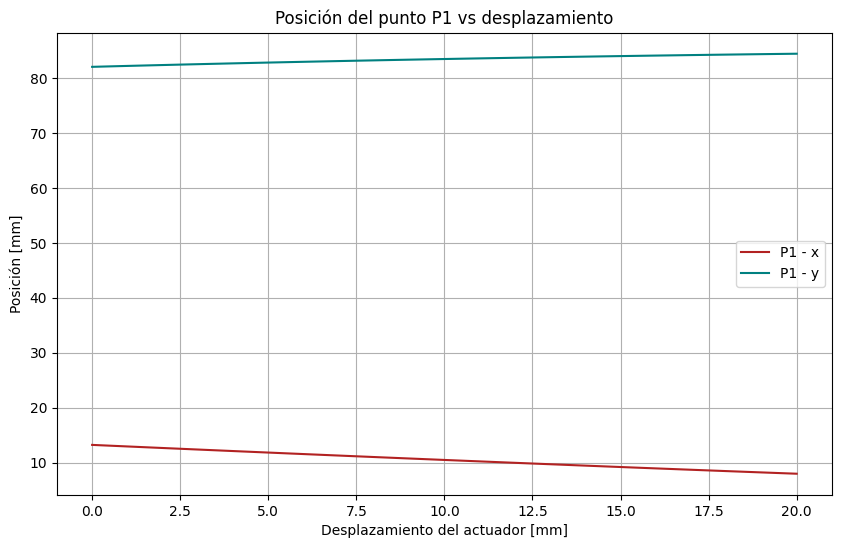

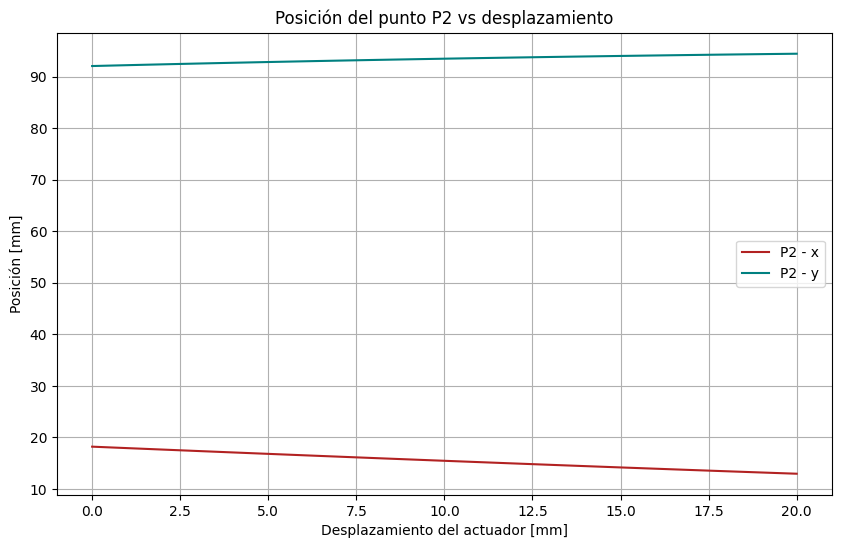

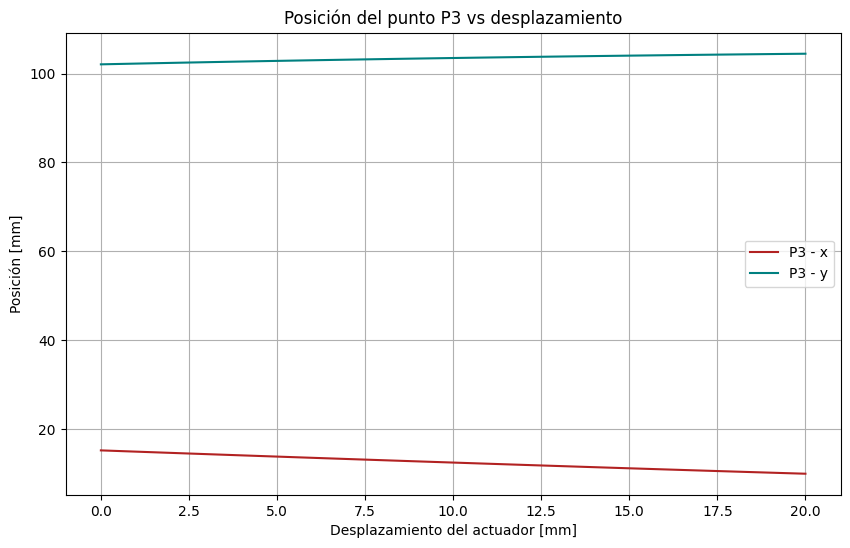

In [73]:
graficar_posiciones_actuador(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3, s_val)

D. Ángulos Respecto al Eje X (En Nuestro Caso Y)

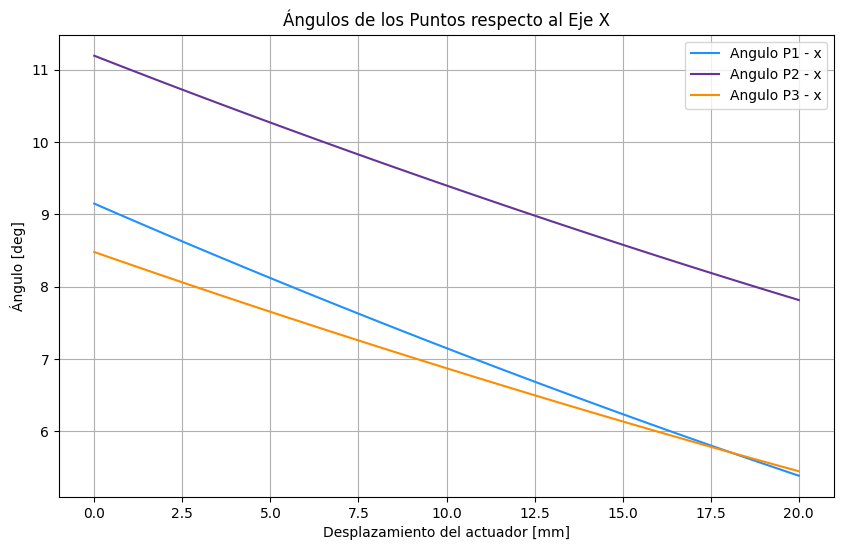

In [75]:
angulos_p1 = angulo_respecto_a_eje(posicionesx_p1, posicionesy_p1)
angulos_p2 = angulo_respecto_a_eje(posicionesx_p2, posicionesy_p2)
angulos_p3 = angulo_respecto_a_eje(posicionesx_p3, posicionesy_p3)
graficar_angulos_actuador(angulos_p1, angulos_p2, angulos_p3, s_val)

E. Datos de Interés para Análisis

In [76]:
# Todos los valores son Respecto al Punto 2 (Promedio)

min_y = min(posicionesy_p2)
max_y = max(posicionesy_p2)
min_x = min(posicionesx_p2)
max_x = max(posicionesx_p2)

print(f" Y Min {min_y}")
print(f" Y Max {max_y}")
print(f" X Min {min_x}")
print(f" X Max {max_x}")

angulo_min_vert = min(angulos_p2)
angulo_max_vert = max(angulos_p2)

print(f" Angulo Min {angulo_min_vert}")
print(f" Angulo Max {angulo_max_vert}")

 Y Min 92.0788228934612
 Y Max 94.46846529989023
 X Min 12.965392874690146
 X Max 18.216612933061082
 Angulo Min 7.81477738698464
 Angulo Max 11.19072774603552


# Punto 3

Aclaración: La razón de los valores negativos asociados a las posiciones corresponden a la elección de los marcos de referencia establecidos en el esquemático. Posteriormente para el análisis se tendrá en cuenta este cambio y se realizarán las adaptaciones correspondientes para la comparación.

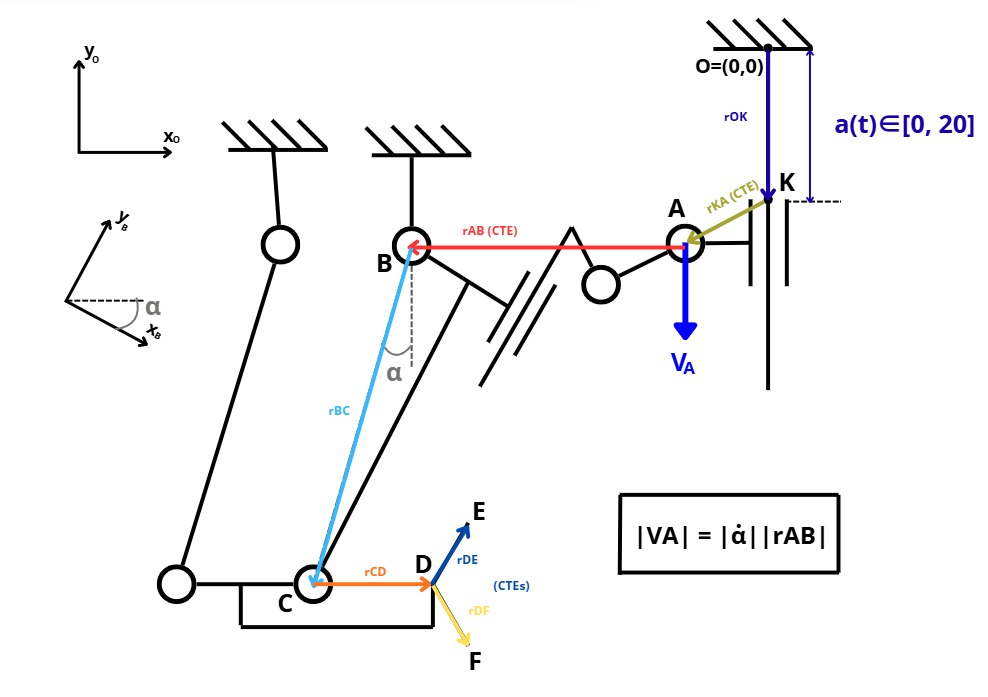

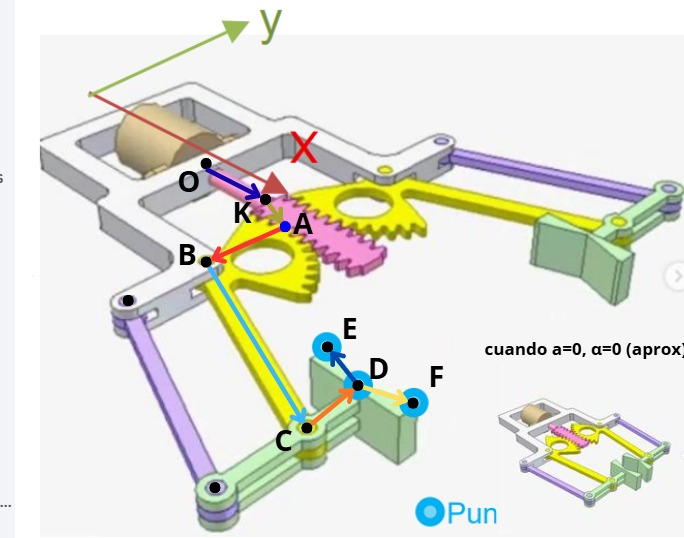

In [82]:
import numpy as np
import sympy
from sympy import symbols
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, init_vprinting

init_vprinting()

# 1. Definición de variables
a, alpha = dynamicsymbols("a, alpha")
t, r_KAx, r_KAy, r_ABx, l_BC, r_CDx, r_DEx, r_DEy = symbols("t, r_KAx, r_KAy, r_ABx, l_BC, r_CDx, r_DEx, r_DEy")

# 2. Fijación de Valores
params = {r_KAx: 5, r_KAy: 10, r_ABx: 25, l_BC: 60, r_CDx: 15, r_DEx: 3, r_DEy: 10}#[mm] a ojo

# 3. Definición de Marcos
O=ReferenceFrame("O")
B=O.orientnew("B", "Axis", (-alpha, O.z))

# 4. Definición de Ecuaciones y Loop
rOK=-a*O.y
rKA=-r_KAx*O.x -r_KAy*O.y
rOA=rOK+rKA
v_A=rOA.diff(t, O)
rAB=-r_ABx*O.x
rBC = -B.y*l_BC
rCD = r_CDx*O.x
rDE = r_DEx*O.x + r_DEy*O.y
rDF = r_DEx*O.x - r_DEy*O.y
rOD=rOA+rAB+rBC+rCD
rOD=rOD.express(O)

# 5. Relaciones angulares
#alpha=integral(alpha_dot, t) con alpha(0)=0, alpha CTE en intervalo, luego alpha(t)=alpha_dot*t
rOD=rOD.subs({alpha: alpha.diff(t)*t})

#Escalarmente, vA=alpha_dot*r_ABx; alpha_dot = vA/r_ABx

vA=rOA.diff(t, O)
vA_norm = sympy.sqrt(vA.dot(O.y)**2)
alpha_dot_norm=vA_norm/r_ABx
display(rOD)

rOD=rOD.subs({alpha.diff(t): alpha_dot_norm})


#Tenemos posición en función de a y su cambio. suponemos que a aumenta linealmente de 0 a 20 en un segundo. Luego a(t) = a't con a' = 20 mm/s 
rOD=rOD.subs({a: a.diff(t)*t})
rOE=rOD+rDE
rOF=rOD+rDF

# 6. Substituciones numéricas

movimiento_a = {a.diff(t, 2): 0, a.diff(t): 20}
rOD=rOD.subs(params).subs(movimiento_a).simplify()
rOE=rOE.subs(params).subs(movimiento_a).simplify()
rOF=rOF.subs(params).subs(movimiento_a).simplify()

# 7. Lambdificación y busqueda de puntos de interés

rODx_fun = sympy.lambdify(t, rOD.dot(O.x), "numpy")
rODy_fun = sympy.lambdify(t, rOD.dot(O.y), "numpy")
rOEx_fun = sympy.lambdify(t, rOE.dot(O.x), "numpy")
rOEy_fun = sympy.lambdify(t, rOE.dot(O.y), "numpy")
rOFx_fun = sympy.lambdify(t, rOF.dot(O.x), "numpy")
rOFy_fun = sympy.lambdify(t, rOF.dot(O.y), "numpy")



B. Trayectoria en el Espacio de los Puntos

B)


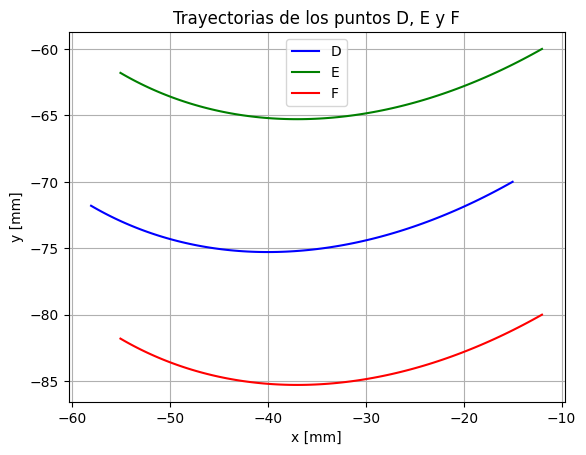

In [83]:
import matplotlib.pyplot as plt
t_linspace = np.linspace(0, 1, 100)
plt.plot(rODx_fun(t_linspace), rODy_fun(t_linspace), label="D", color="blue")
plt.plot(rOEx_fun(t_linspace), rOEy_fun(t_linspace), label="E", color="green")
plt.plot(rOFx_fun(t_linspace), rOFy_fun(t_linspace), label="F", color="red")

plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("Trayectorias de los puntos D, E y F")
plt.legend()
plt.grid(True)

print("B)")
plt.show()

C. Posición en Función del Desplazamiento del Actuador Lineal

C)


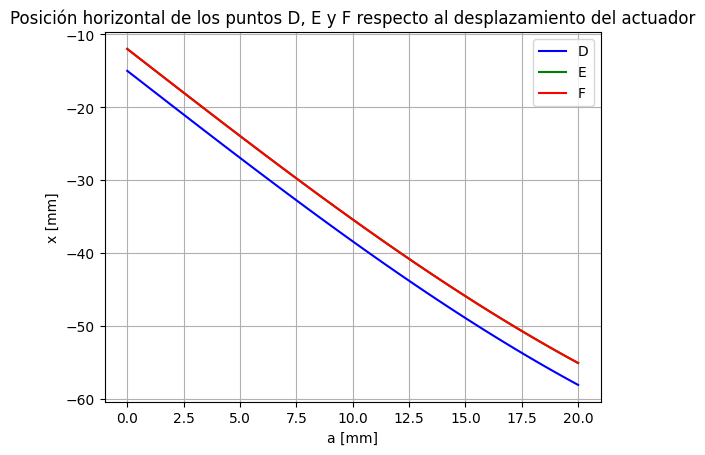

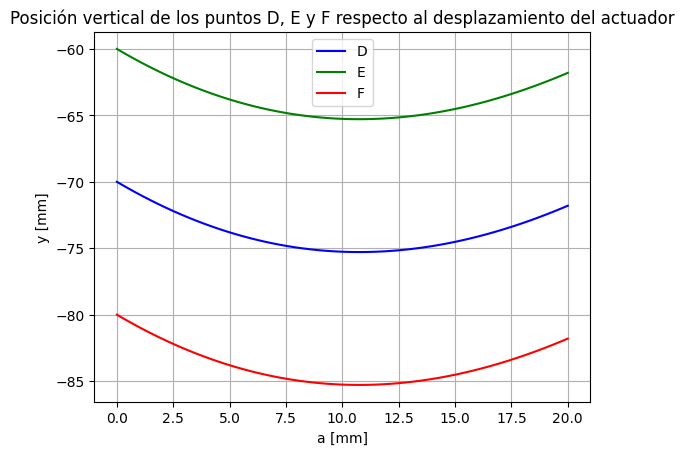

In [84]:
#C: x vs a, y vs a. Simplemente hacemos la sustitución t=a/a'
print("C)")
rOD=rOD.subs({t: a/20})
rOE=rOE.subs({t: a/20})
rOF=rOF.subs({t: a/20})
rODx_fun = sympy.lambdify(a, rOD.dot(O.x), "numpy")
rODy_fun = sympy.lambdify(a, rOD.dot(O.y), "numpy")
rOEx_fun = sympy.lambdify(a, rOE.dot(O.x), "numpy")
rOEy_fun = sympy.lambdify(a, rOE.dot(O.y), "numpy")
rOFx_fun = sympy.lambdify(a, rOF.dot(O.x), "numpy")
rOFy_fun = sympy.lambdify(a, rOF.dot(O.y), "numpy")
a_linspace = np.linspace(0, 20, 100)

plt.plot(a_linspace, rODx_fun(a_linspace), label="D", color="blue")
plt.plot(a_linspace, rOEx_fun(a_linspace), label="E", color="green")
plt.plot(a_linspace, rOFx_fun(a_linspace), label="F", color="red")
plt.xlabel("a [mm]")
plt.ylabel("x [mm]")
plt.title("Posición horizontal de los puntos D, E y F respecto al desplazamiento del actuador")
plt.legend()
plt.grid(True)
plt.show()


plt.plot(a_linspace, rODy_fun(a_linspace), label="D", color="blue")
plt.plot(a_linspace, rOEy_fun(a_linspace), label="E", color="green")
plt.plot(a_linspace, rOFy_fun(a_linspace), label="F", color="red")
plt.xlabel("a [mm]")
plt.ylabel("y [mm]")
plt.title("Posición vertical de los puntos D, E y F respecto al desplazamiento del actuador")
plt.legend()
plt.grid(True)
plt.show()

D. Ángulos Respecto al Eje Axial

D)


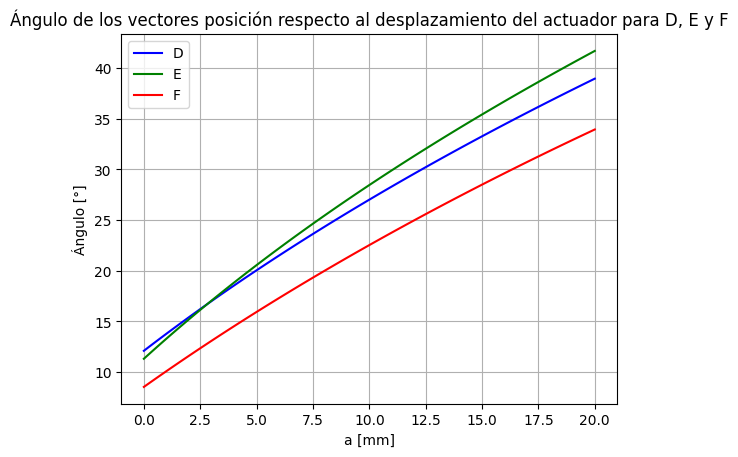

In [85]:
#Ángulo entre eje x y vectores posición en función de a. Como ambas componentes son negativas, el ángulo estará en el tercer cuadrante, por lo que se puede usar arctan(x/y) para obtenerlo.

plt.plot(a_linspace, np.arctan(rODx_fun(a_linspace)/rODy_fun(a_linspace)) * 180 / np.pi, label="D", color="blue")
plt.plot(a_linspace, np.arctan(rOEx_fun(a_linspace)/rOEy_fun(a_linspace)) * 180 / np.pi, label="E", color="green")
plt.plot(a_linspace, np.arctan(rOFx_fun(a_linspace)/rOFy_fun(a_linspace)) * 180 / np.pi, label="F", color="red")

plt.xlabel("a [mm]")
plt.ylabel("Ángulo [°]")
plt.title("Ángulo de los vectores posición respecto al desplazamiento del actuador para D, E y F")
plt.legend()
plt.grid(True)

print("D)")
plt.show()
plt.show()